In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 
import statsmodels.api as sm
from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Define paths
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path = '../../hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [3]:
import pandas as pd
import re

gff_path = '/gale/raidix/rdx-7/jwalker/Kay_Qu/c1038_genes_overlapping_c2952_dmw_chunks.gff'

# 1. Read the GFF (Skipping comment lines starting with '#')
# GFFs are tab-separated and have 9 standard columns
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
df_gff = pd.read_csv(gff_path, sep='\t', comment='#', header=None, names=gff_cols)

# 2. Filter for 'gene' features only (Column 3)
genes_only = df_gff[df_gff['type'] == 'gene'].copy()

# 3. Extract the ID from the 'attributes' column
# Usually looks like: "ID=gene:AT1G01010;Name=..." or "ID=AT1G01010"
def extract_id(attr_string):
    # This regex looks for 'ID=' followed by characters until a semicolon or end of string
    match = re.search(r'ID=([^;]+)', attr_string)
    if match:
        gene_id = match.group(1)
        # Clean up common prefixes like 'gene:' if they exist
        return gene_id.replace('gene:', '')
    return None

# Apply the extraction
new_gene_list = genes_only['attributes'].apply(extract_id).dropna().unique().tolist()

# 4. Update your pipeline variable
hazel_genes = pd.Index(new_gene_list)

print(f"✅ Loaded {len(hazel_genes)} unique Gene IDs from the GFF file.")
print(f"Sample IDs: {new_gene_list[:5]}")

✅ Loaded 1038 unique Gene IDs from the GFF file.
Sample IDs: ['AT1G01300', 'AT1G01770', 'AT1G01780', 'AT1G01830', 'AT1G01950']


In [4]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# Aggregate by cluster
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 17)


In [5]:
# Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

mCGN_mc['cluster'] = meta['merged_cluster']
mCGN_cov['cluster'] = meta['merged_cluster']

# Aggregate counts by cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T  # Shape: (genes, clusters)
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
# Aggregate across all genes per cluster
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation (p0) ---
# Gene-wise baseline (pbar)
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# Mask genes with extremely low total coverage to avoid noise
valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m = cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)

# Broadcast expected values: p0 = expit(logit(pbar) + deltas)
# pbar is (genes,), deltas is (clusters,). We create a (genes, clusters) matrix
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Adjusted Matrix ---
# Observed fractions
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

# Residuals: observed deviation from the cluster's global logit expectation
adj_meth_matrix = obs_p - p0_df

# Filter for genes that actually have meaningful methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13764, 17)


In [6]:

# Align genes across modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

# We will use the total coverage (cluster_m) as our weights
final_weights_df = cluster_m.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    # Skip genes with zero variance in either modality
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    # Standardize to make the WLS coefficient behave like a correlation coefficient (Rho)
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    
    # Add constant for intercept
    X = sm.add_constant(meth_z)
    
    try:
        # Fit Weighted Least Squares
        # Endog (Y) = RNA, Exog (X) = Methylation
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        
        # Extract the slope coefficient (pseudo-rho) and its p-value
        # Index 1 is the slope for 'meth_z' (Index 0 is the constant)
        rho = wls_model.params[1] 
        p = wls_model.pvalues[1]
        
        valid_genes.append(gene)
        correlations.append(rho)
        p_values.append(p)
    except Exception:
        # Catch any convergence errors for extremely sparse genes
        continue

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes (WLS, Coverage-Weighted):")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes (WLS, Coverage-Weighted):
                rho   p_value       fdr
gene                                   
AT2G04790 -1.732238  0.000114  0.032653
AT2G07713 -1.663293  0.047919  0.496955
AT1G55370 -1.634012  0.000215  0.045561
AT5G35490 -1.449742  0.000016  0.008352
AT3G29639 -1.407684  0.003538  0.209529
AT2G04825 -1.384154  0.003283  0.206739
AT1G52240 -1.302113  0.001152  0.122335
AT3G21670 -1.298125  0.000027  0.011065
AT3G55735 -1.297038  0.000452  0.069419
AT3G26290 -1.294671  0.000006  0.004282
AT5G49740 -1.251251  0.000018  0.008440
AT2G05615 -1.246359  0.018173  0.376778
AT4G04330 -1.238686  0.014208  0.341467
AT3G29033 -1.235975  0.041621  0.471824
AT4G04265 -1.222466  0.010509  0.302969
AT5G23060 -1.201050  0.020242  0.387271
AT2G07764 -1.197692  0.272472  0.744871
AT5G57760 -1.196886  0.000578  0.081813
AT1G58290 -1.196723  0.000166  0.039083
AT4G38870 -1.191051  0.002114  0.173913


Processing: 1_All_Clusters...


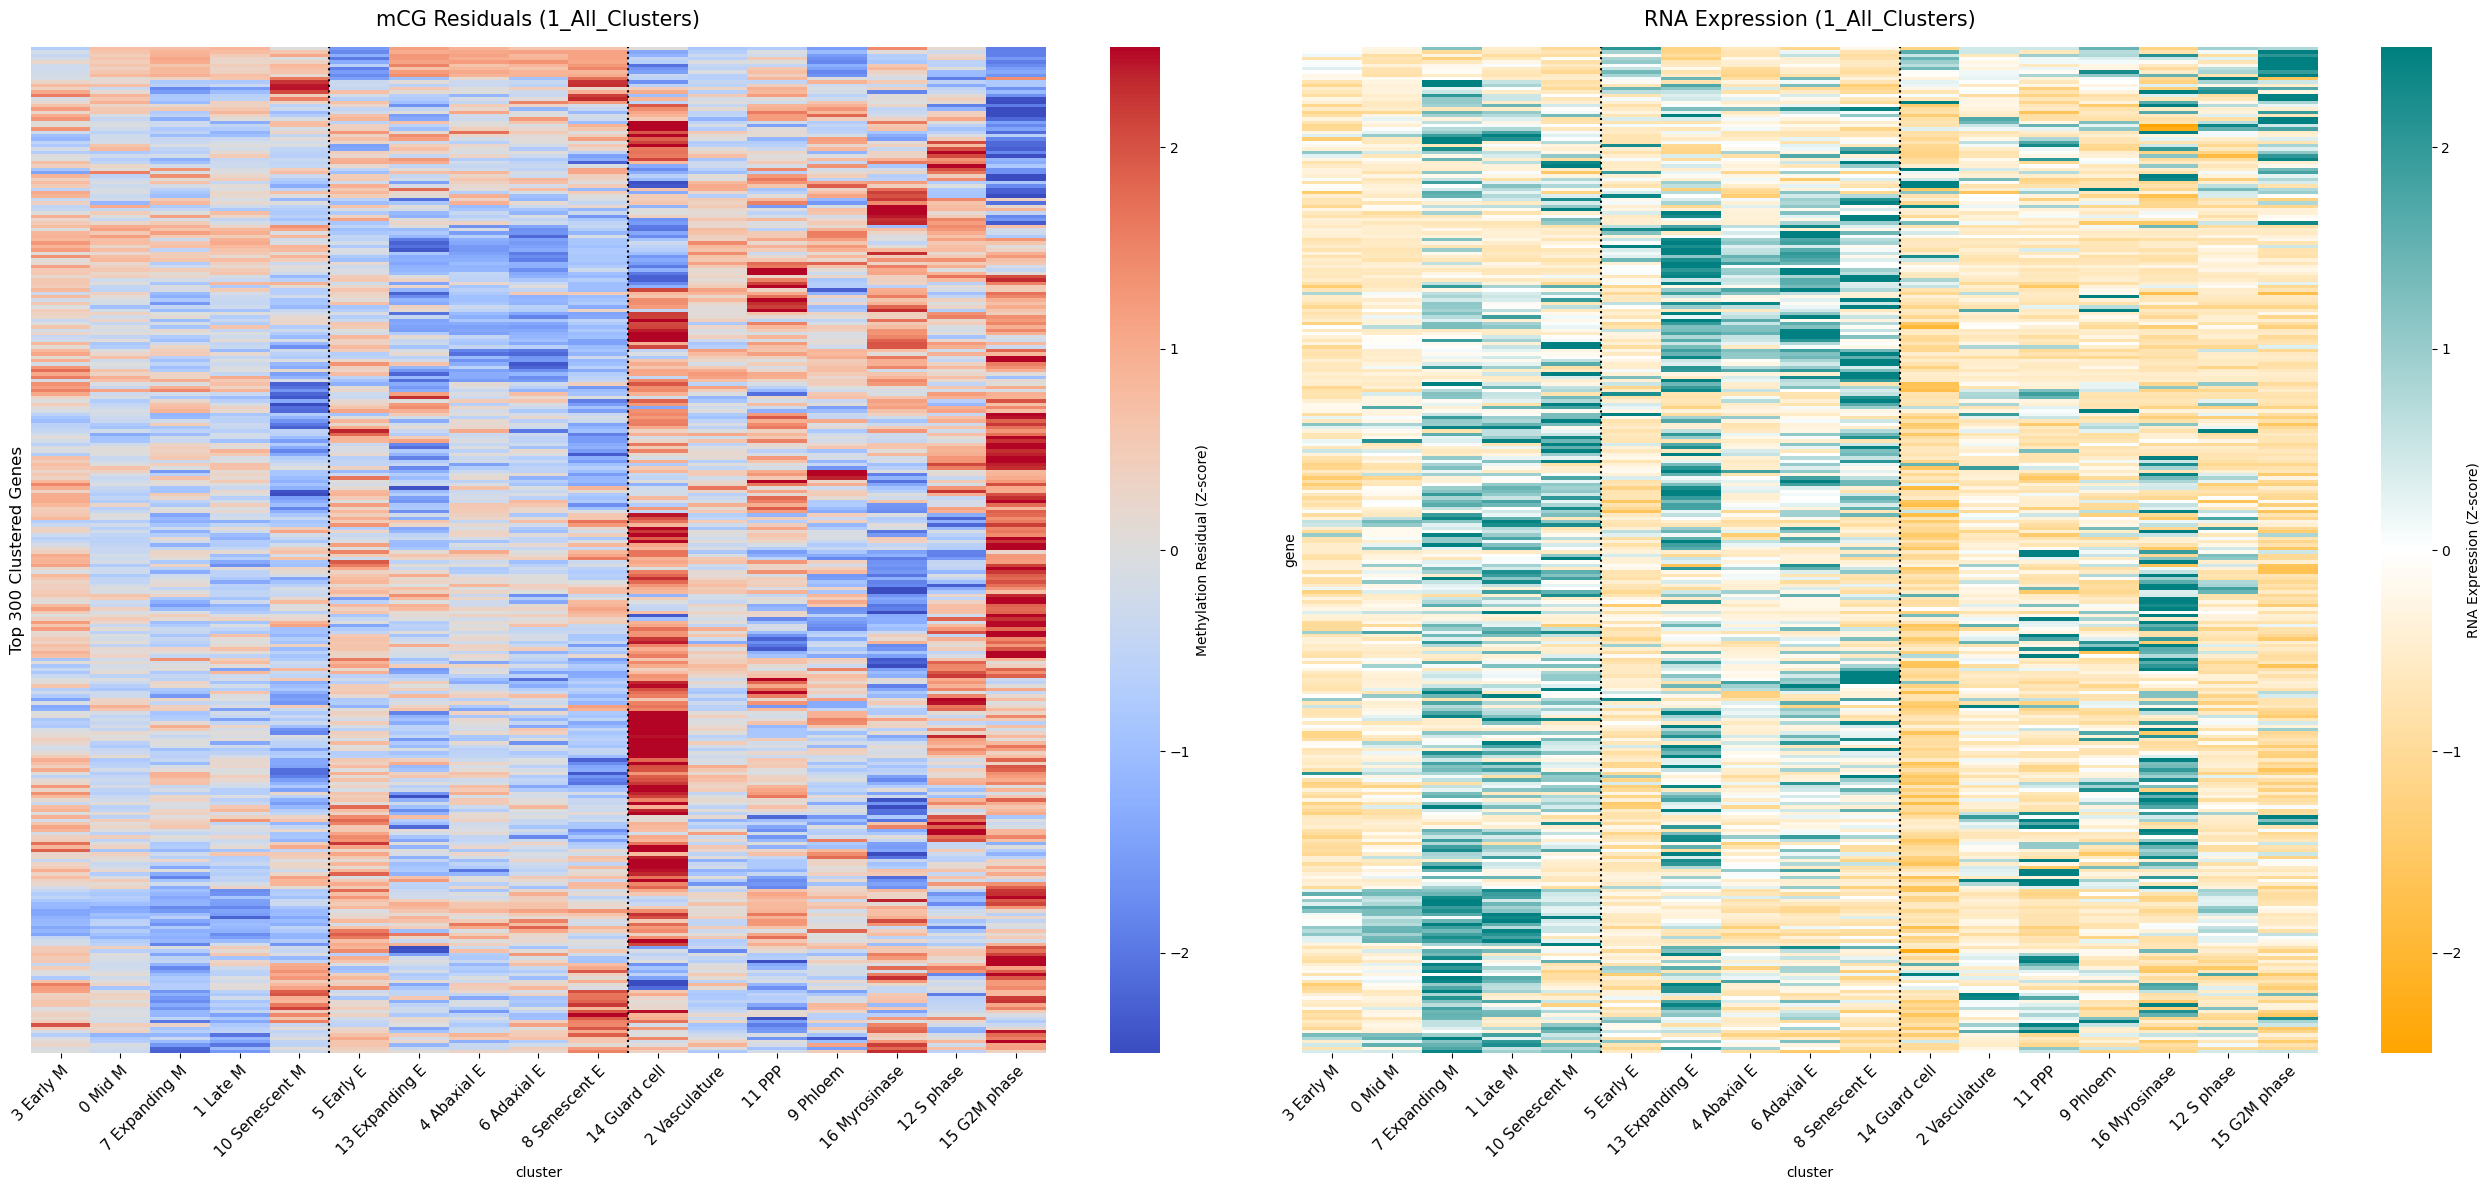

Processing: 2_Meta_States...


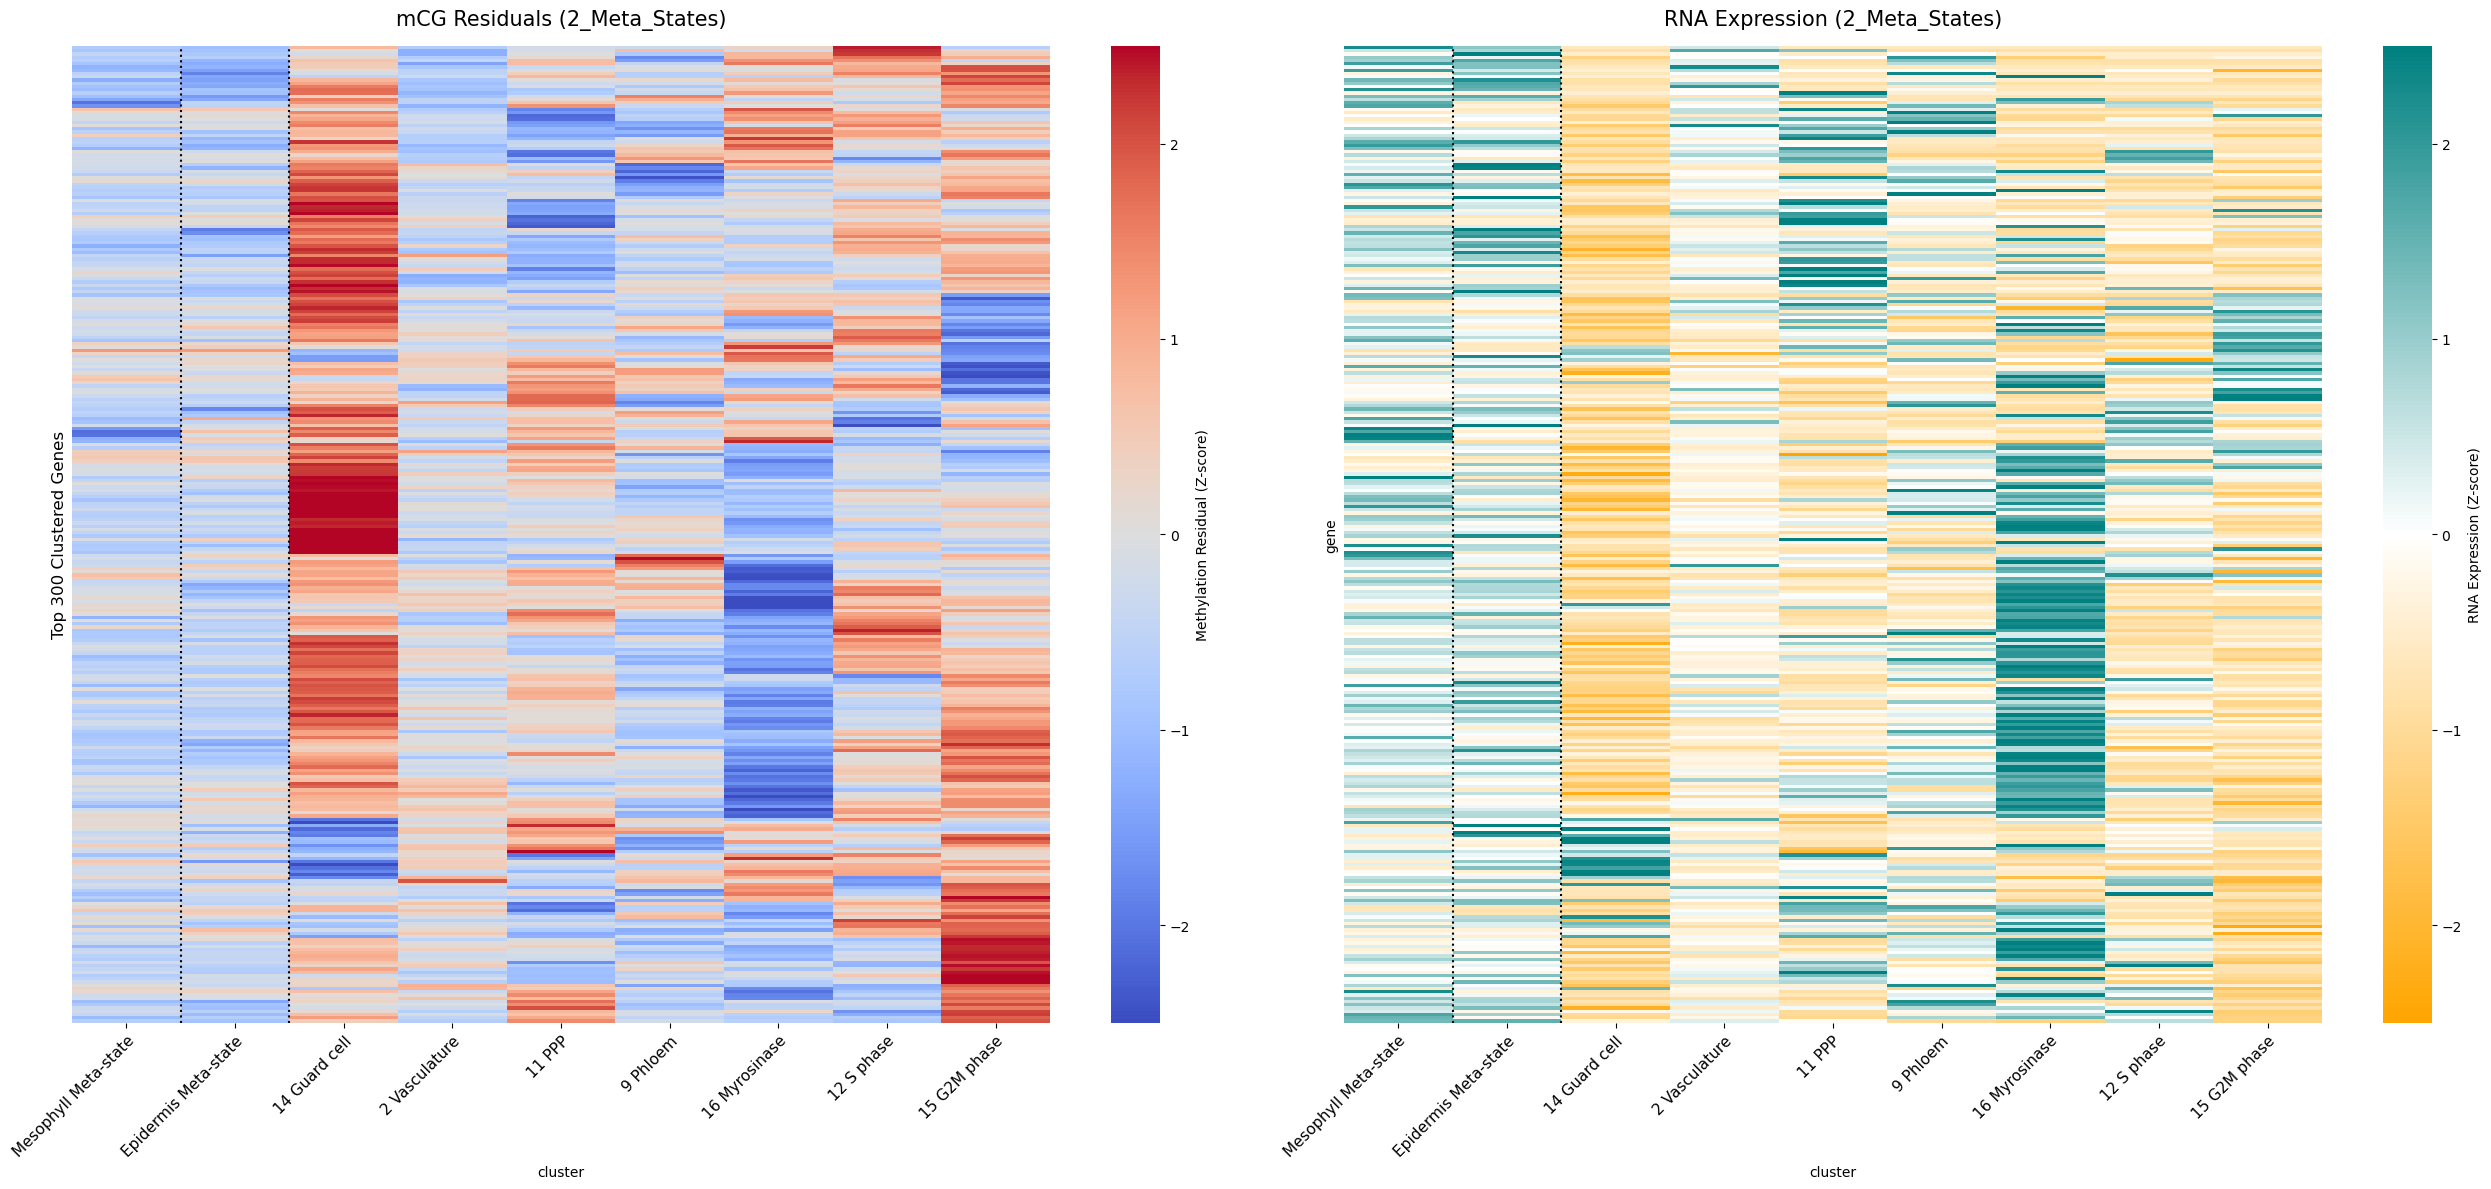

Processing: 3_Mesophyll_Only...


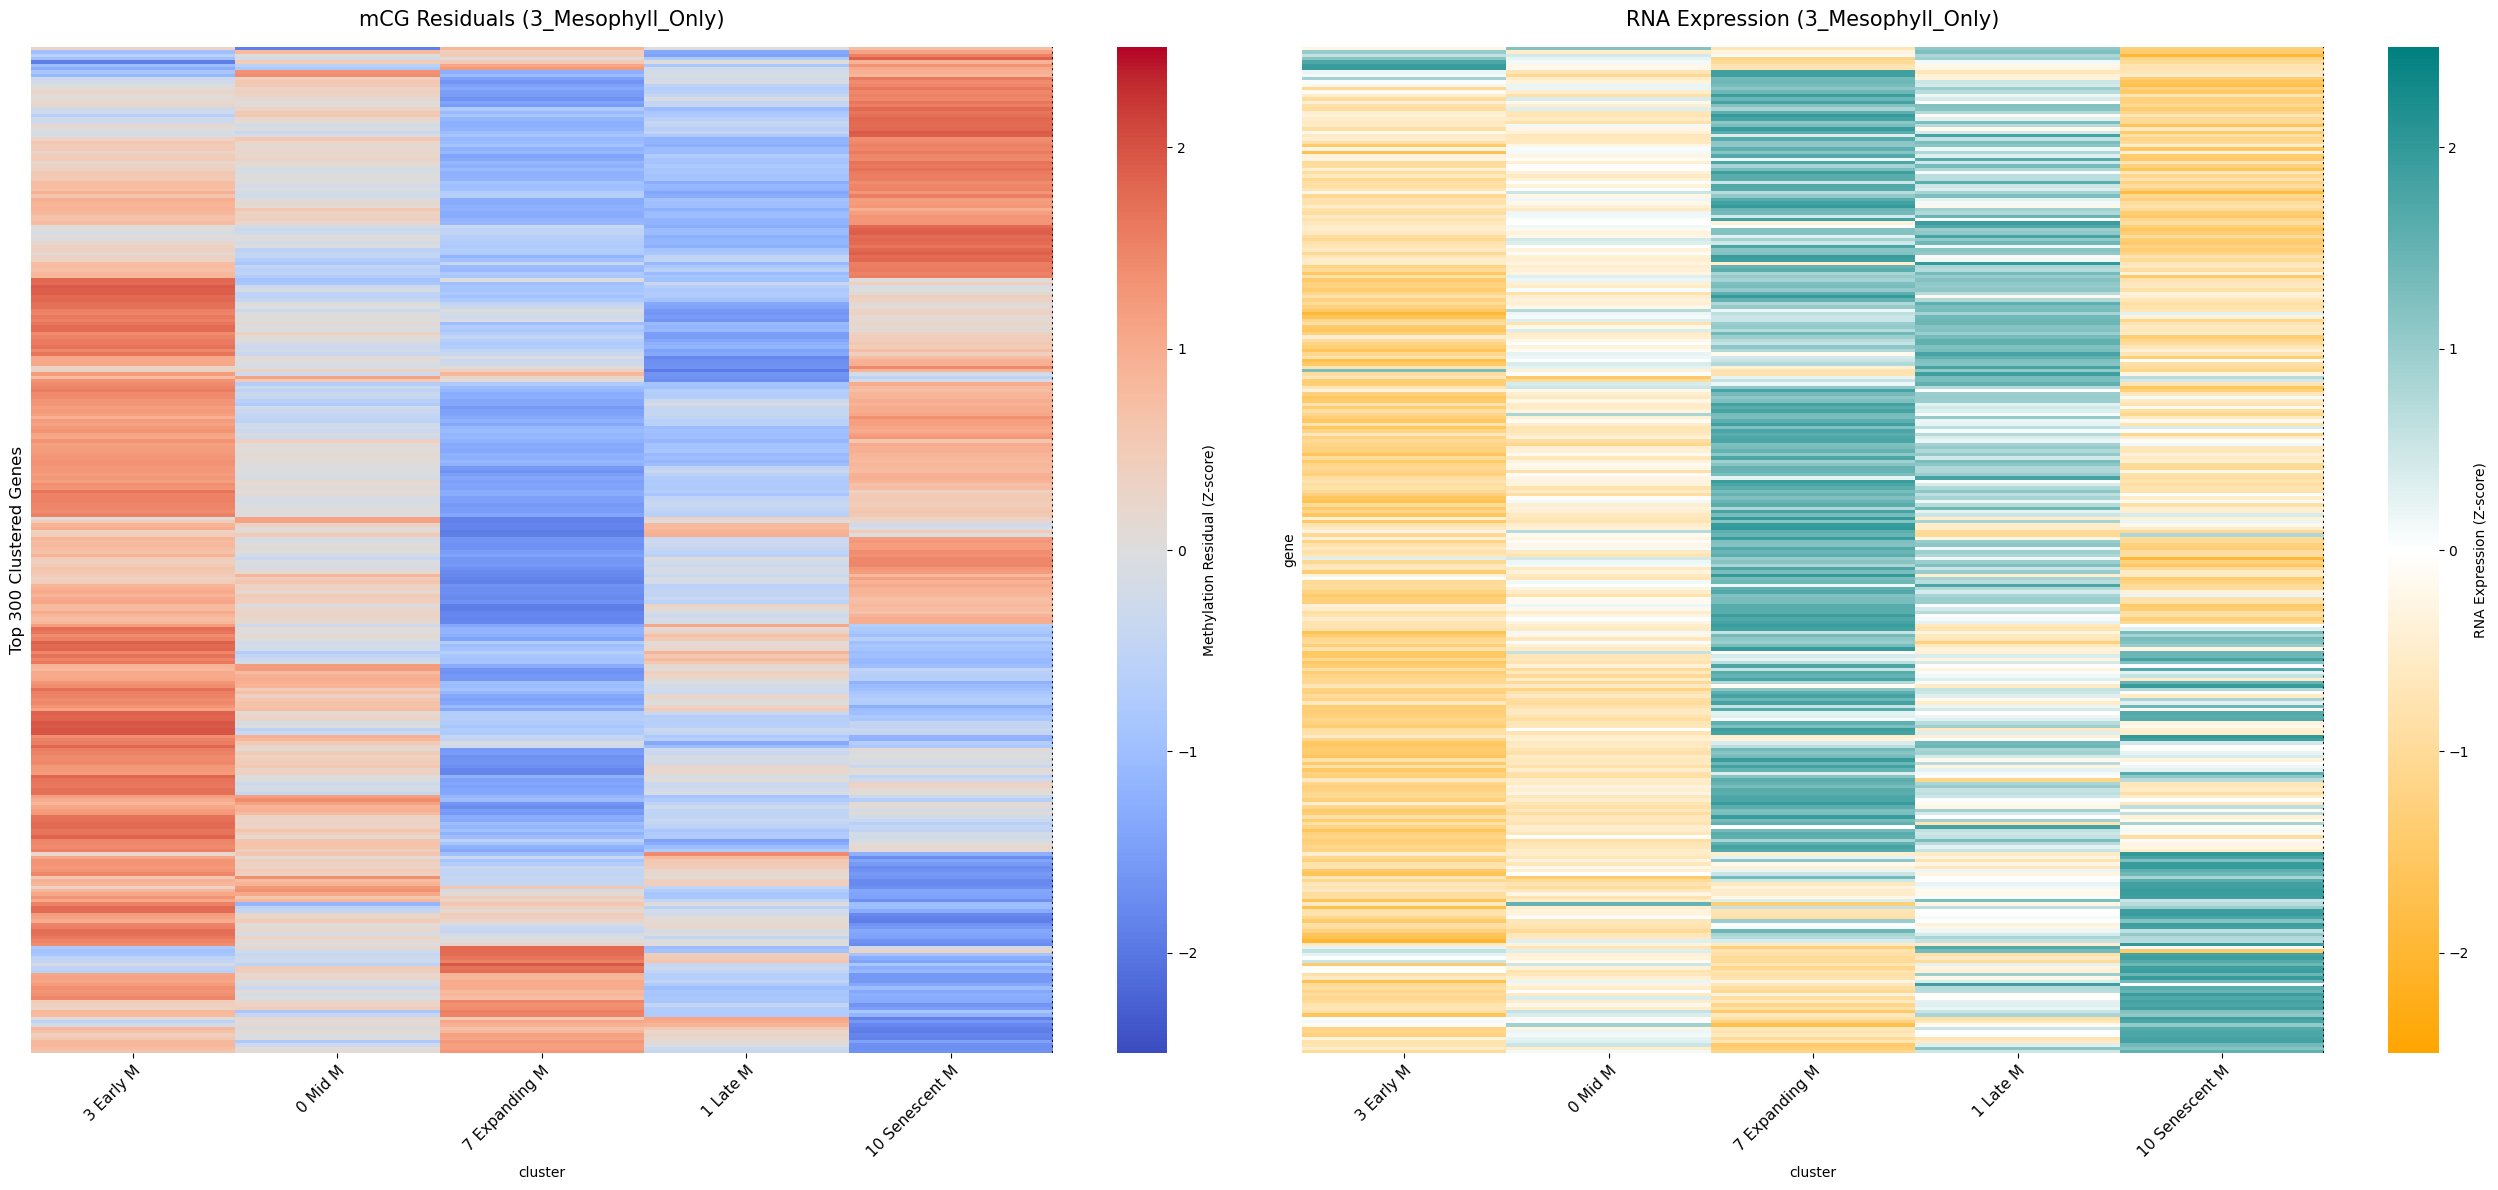

Processing: 4_Epidermis_Only...


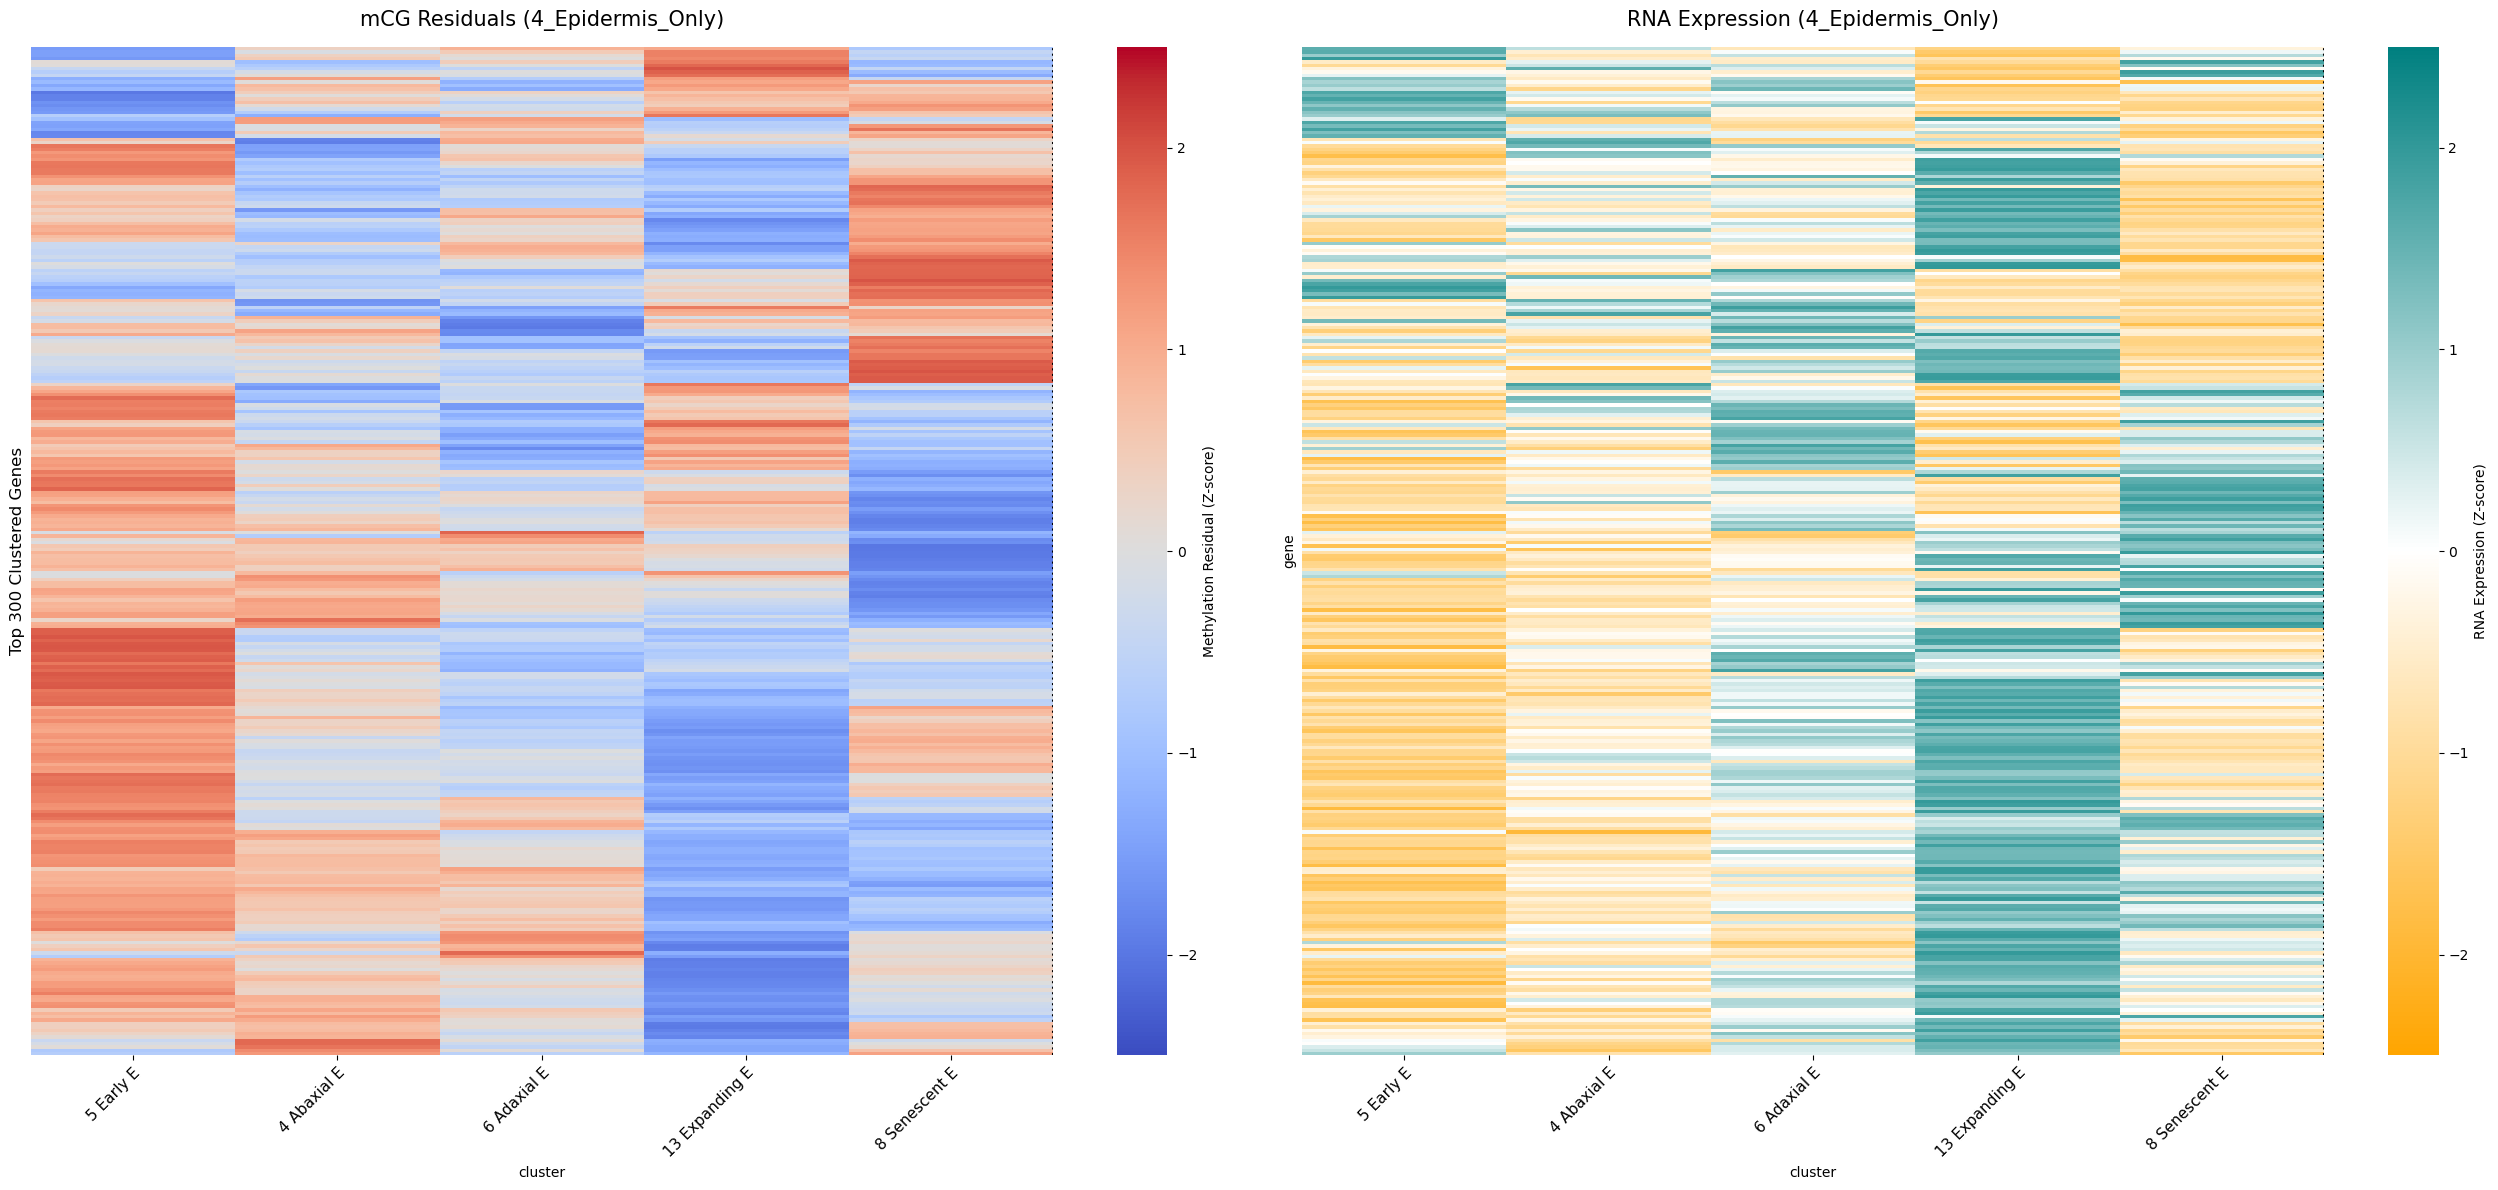

Processing: 5_Non_Meso_Epi...


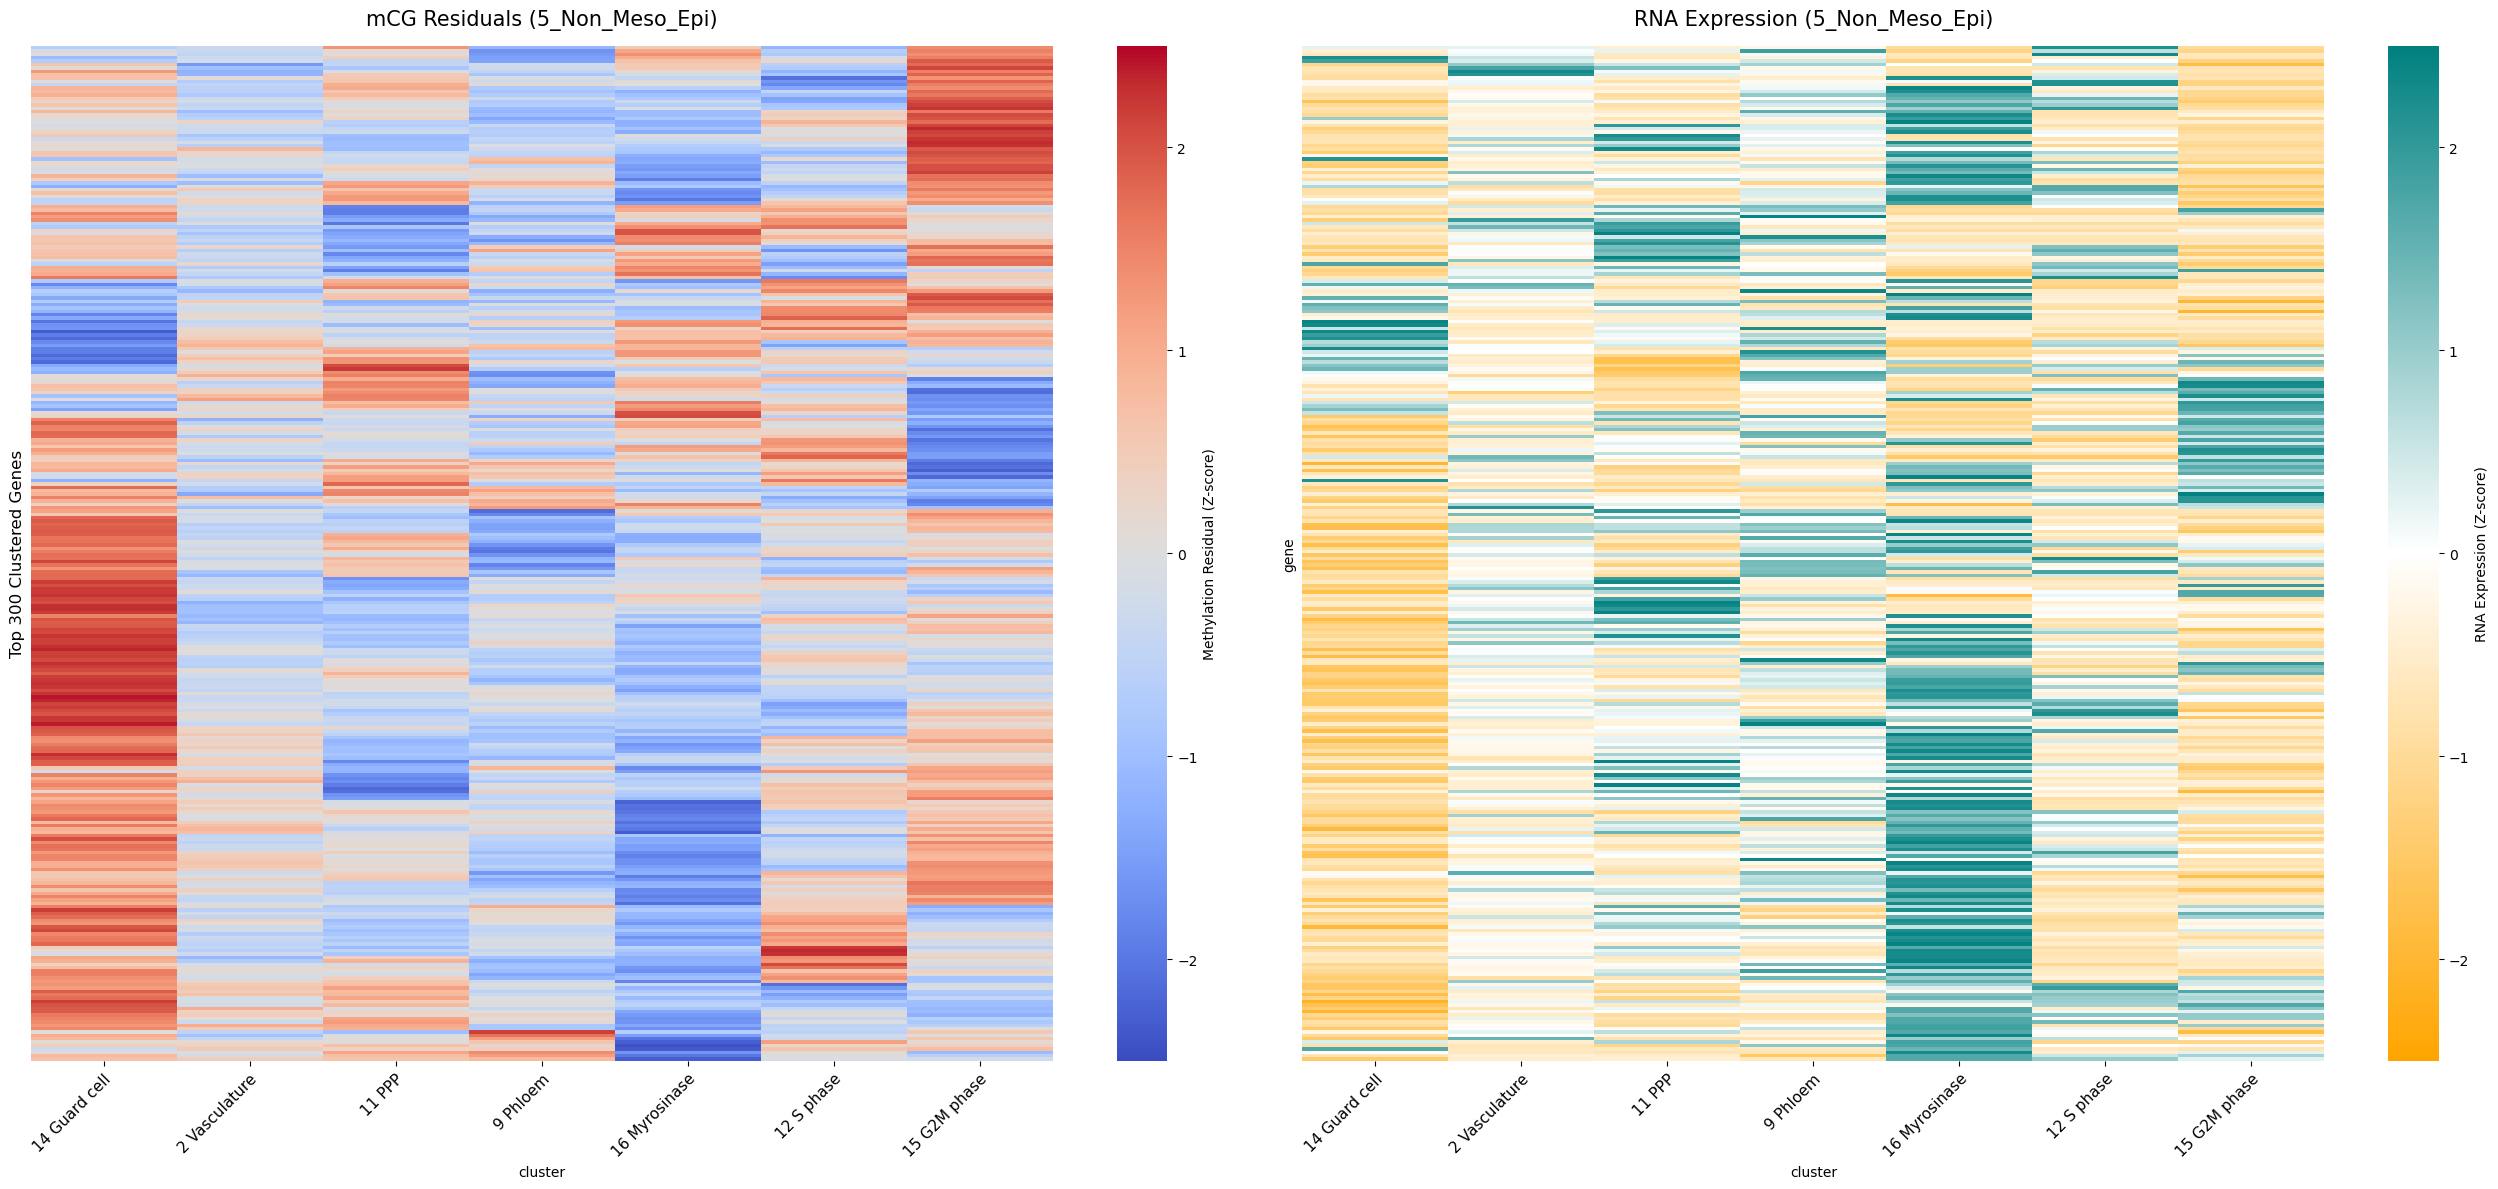

Processing: 6_Terminal_Non_Meso_Epi...


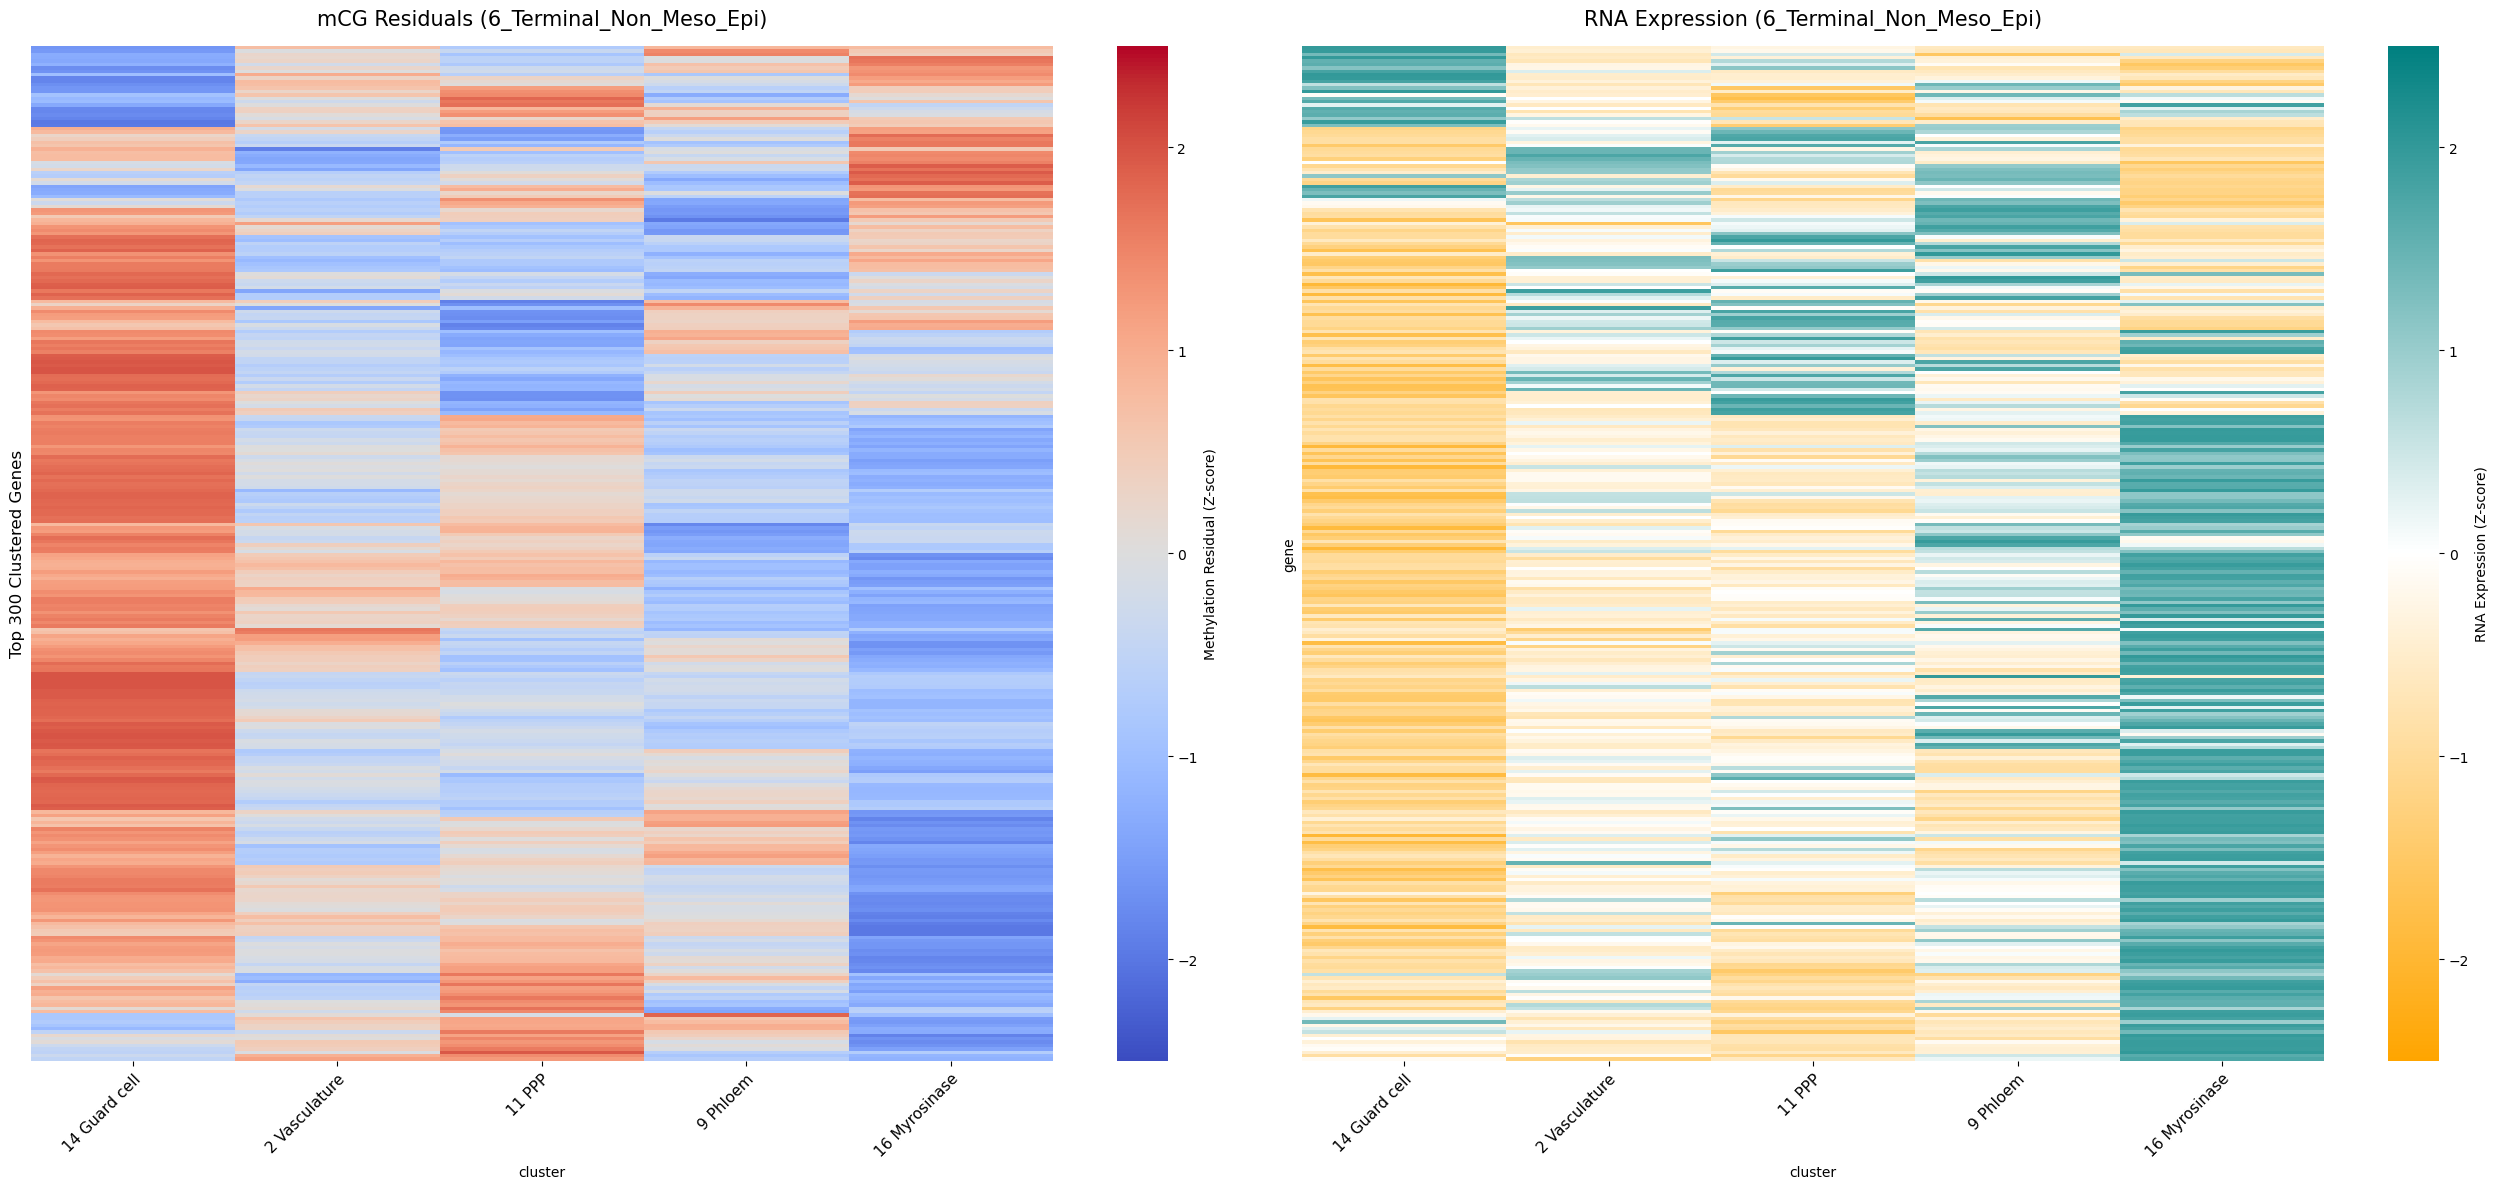

Processing: 7_Terminal_Ex_Guard...


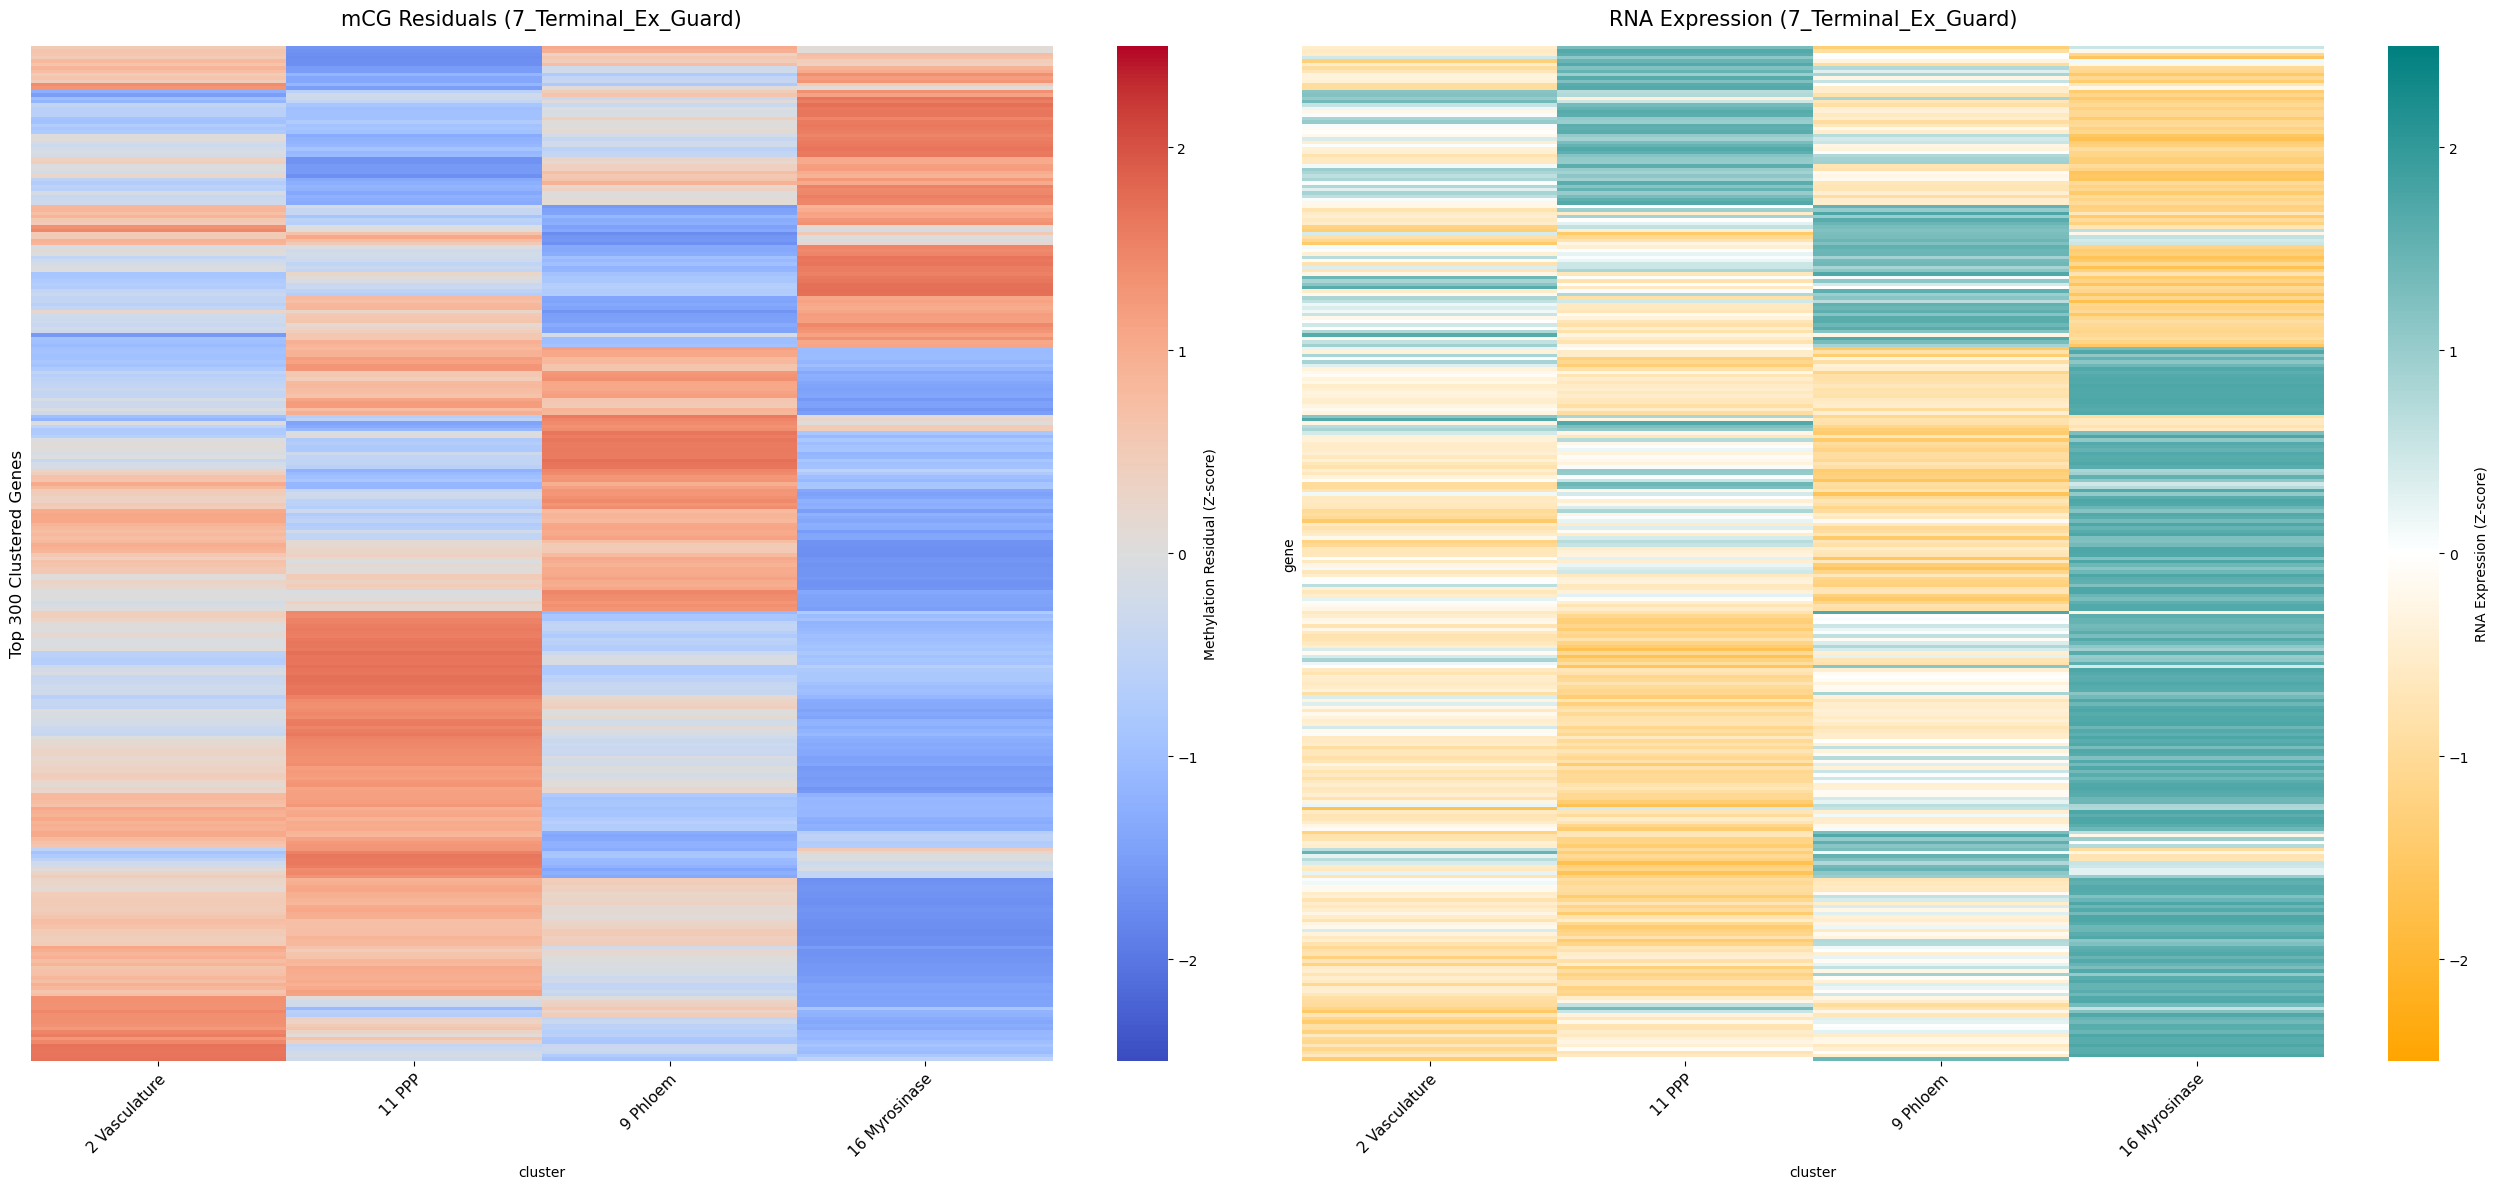

Processing: 8_All_Ex_Guard_G2M...


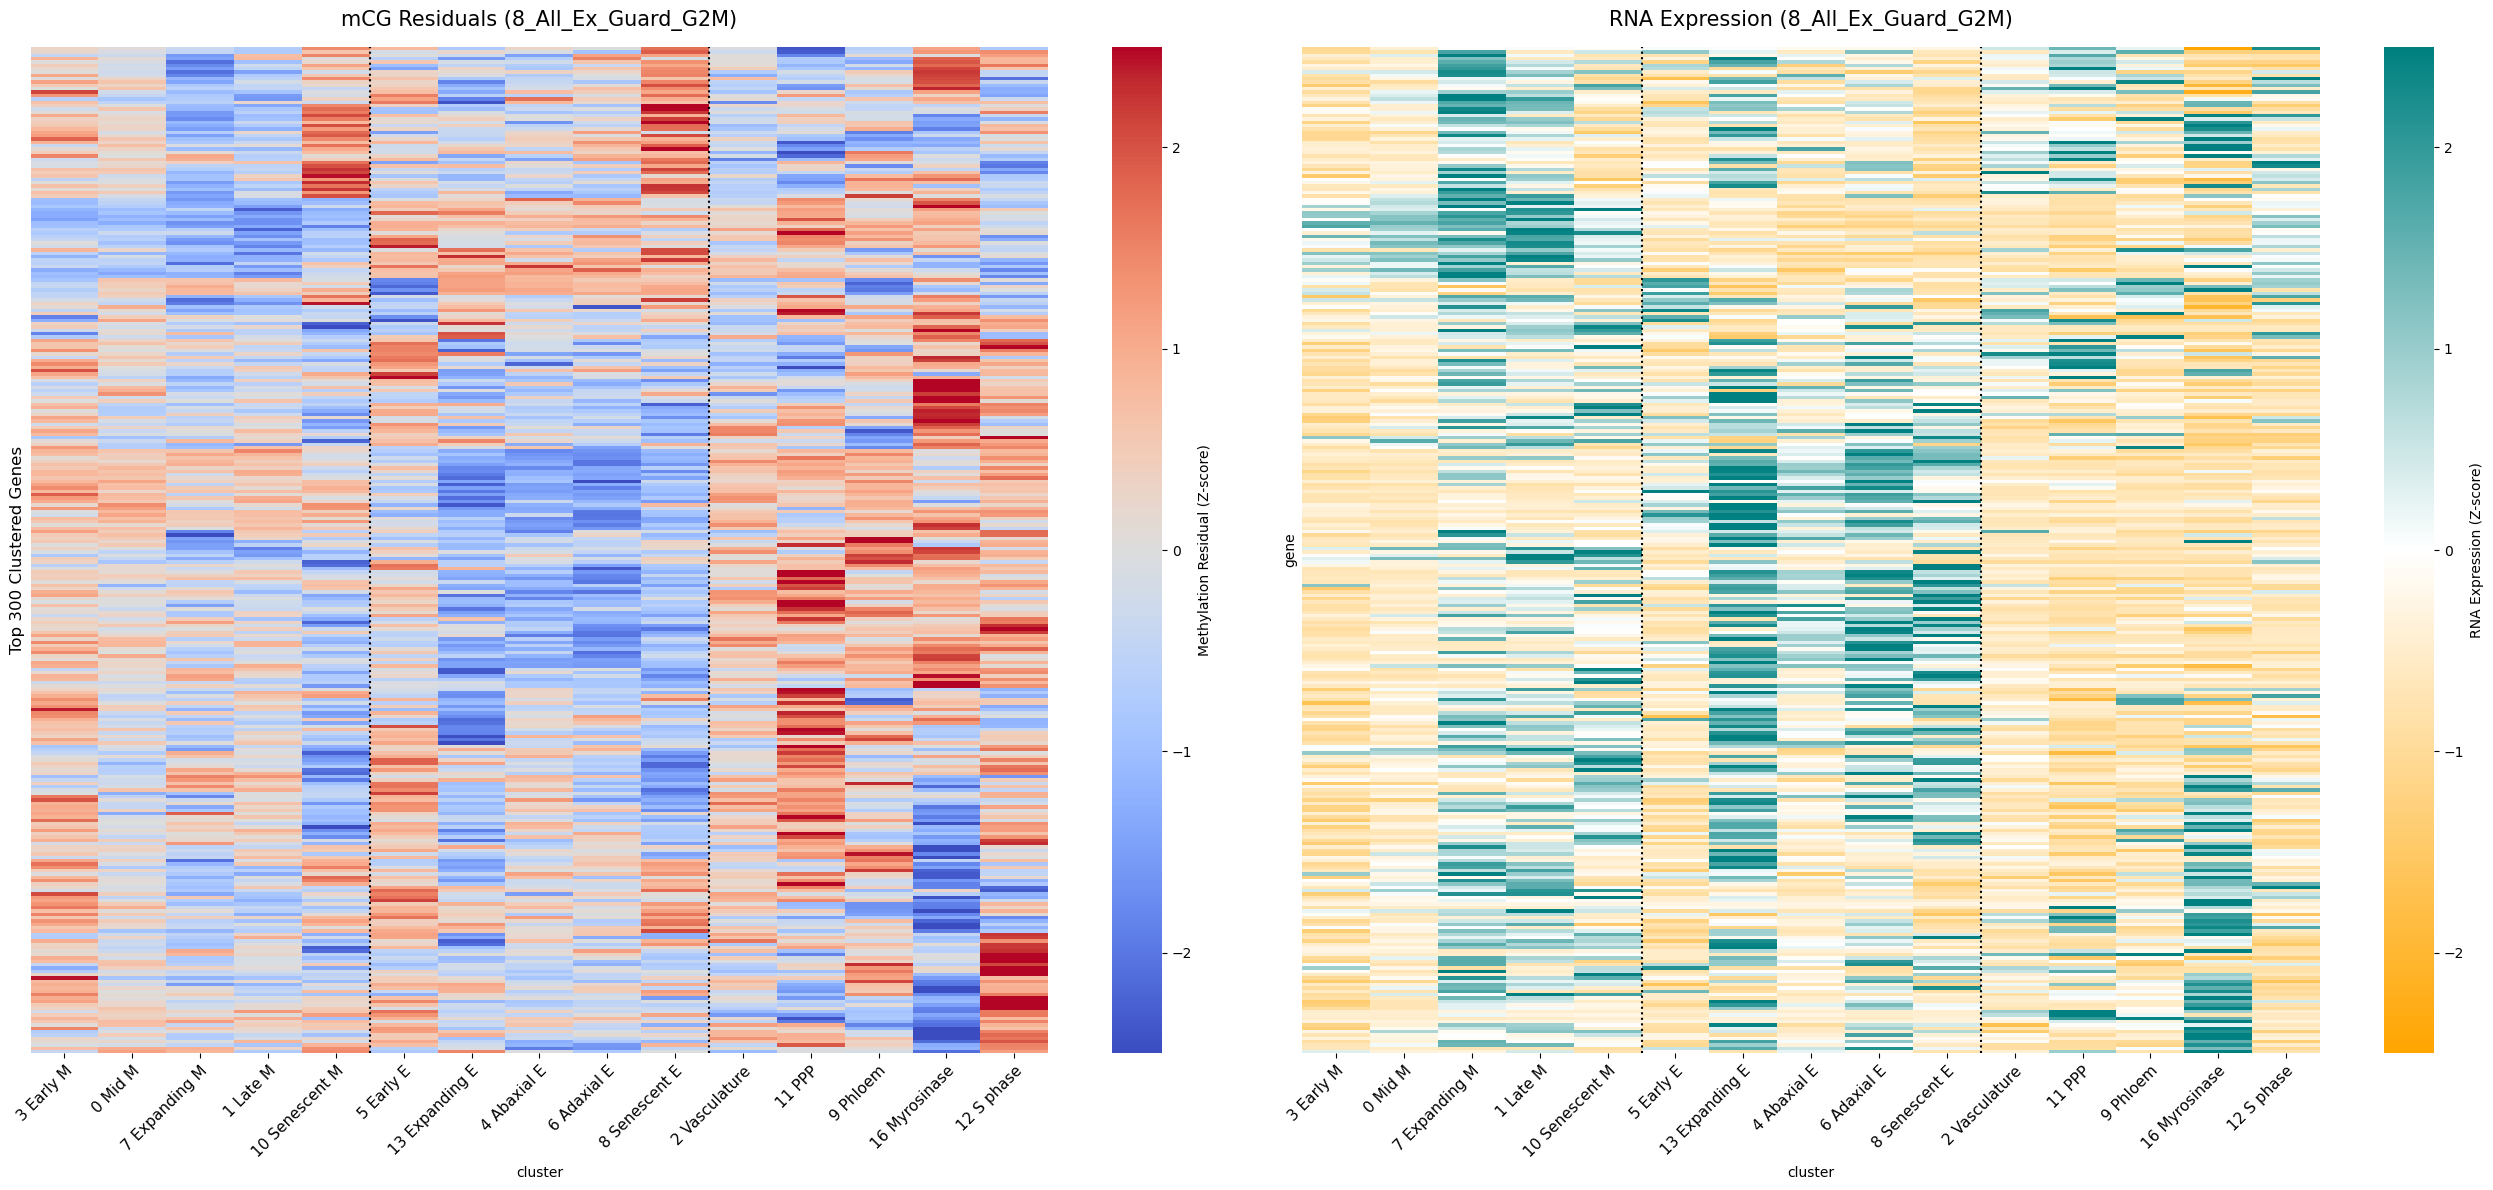

Processing: 9_Meso_and_Epi...


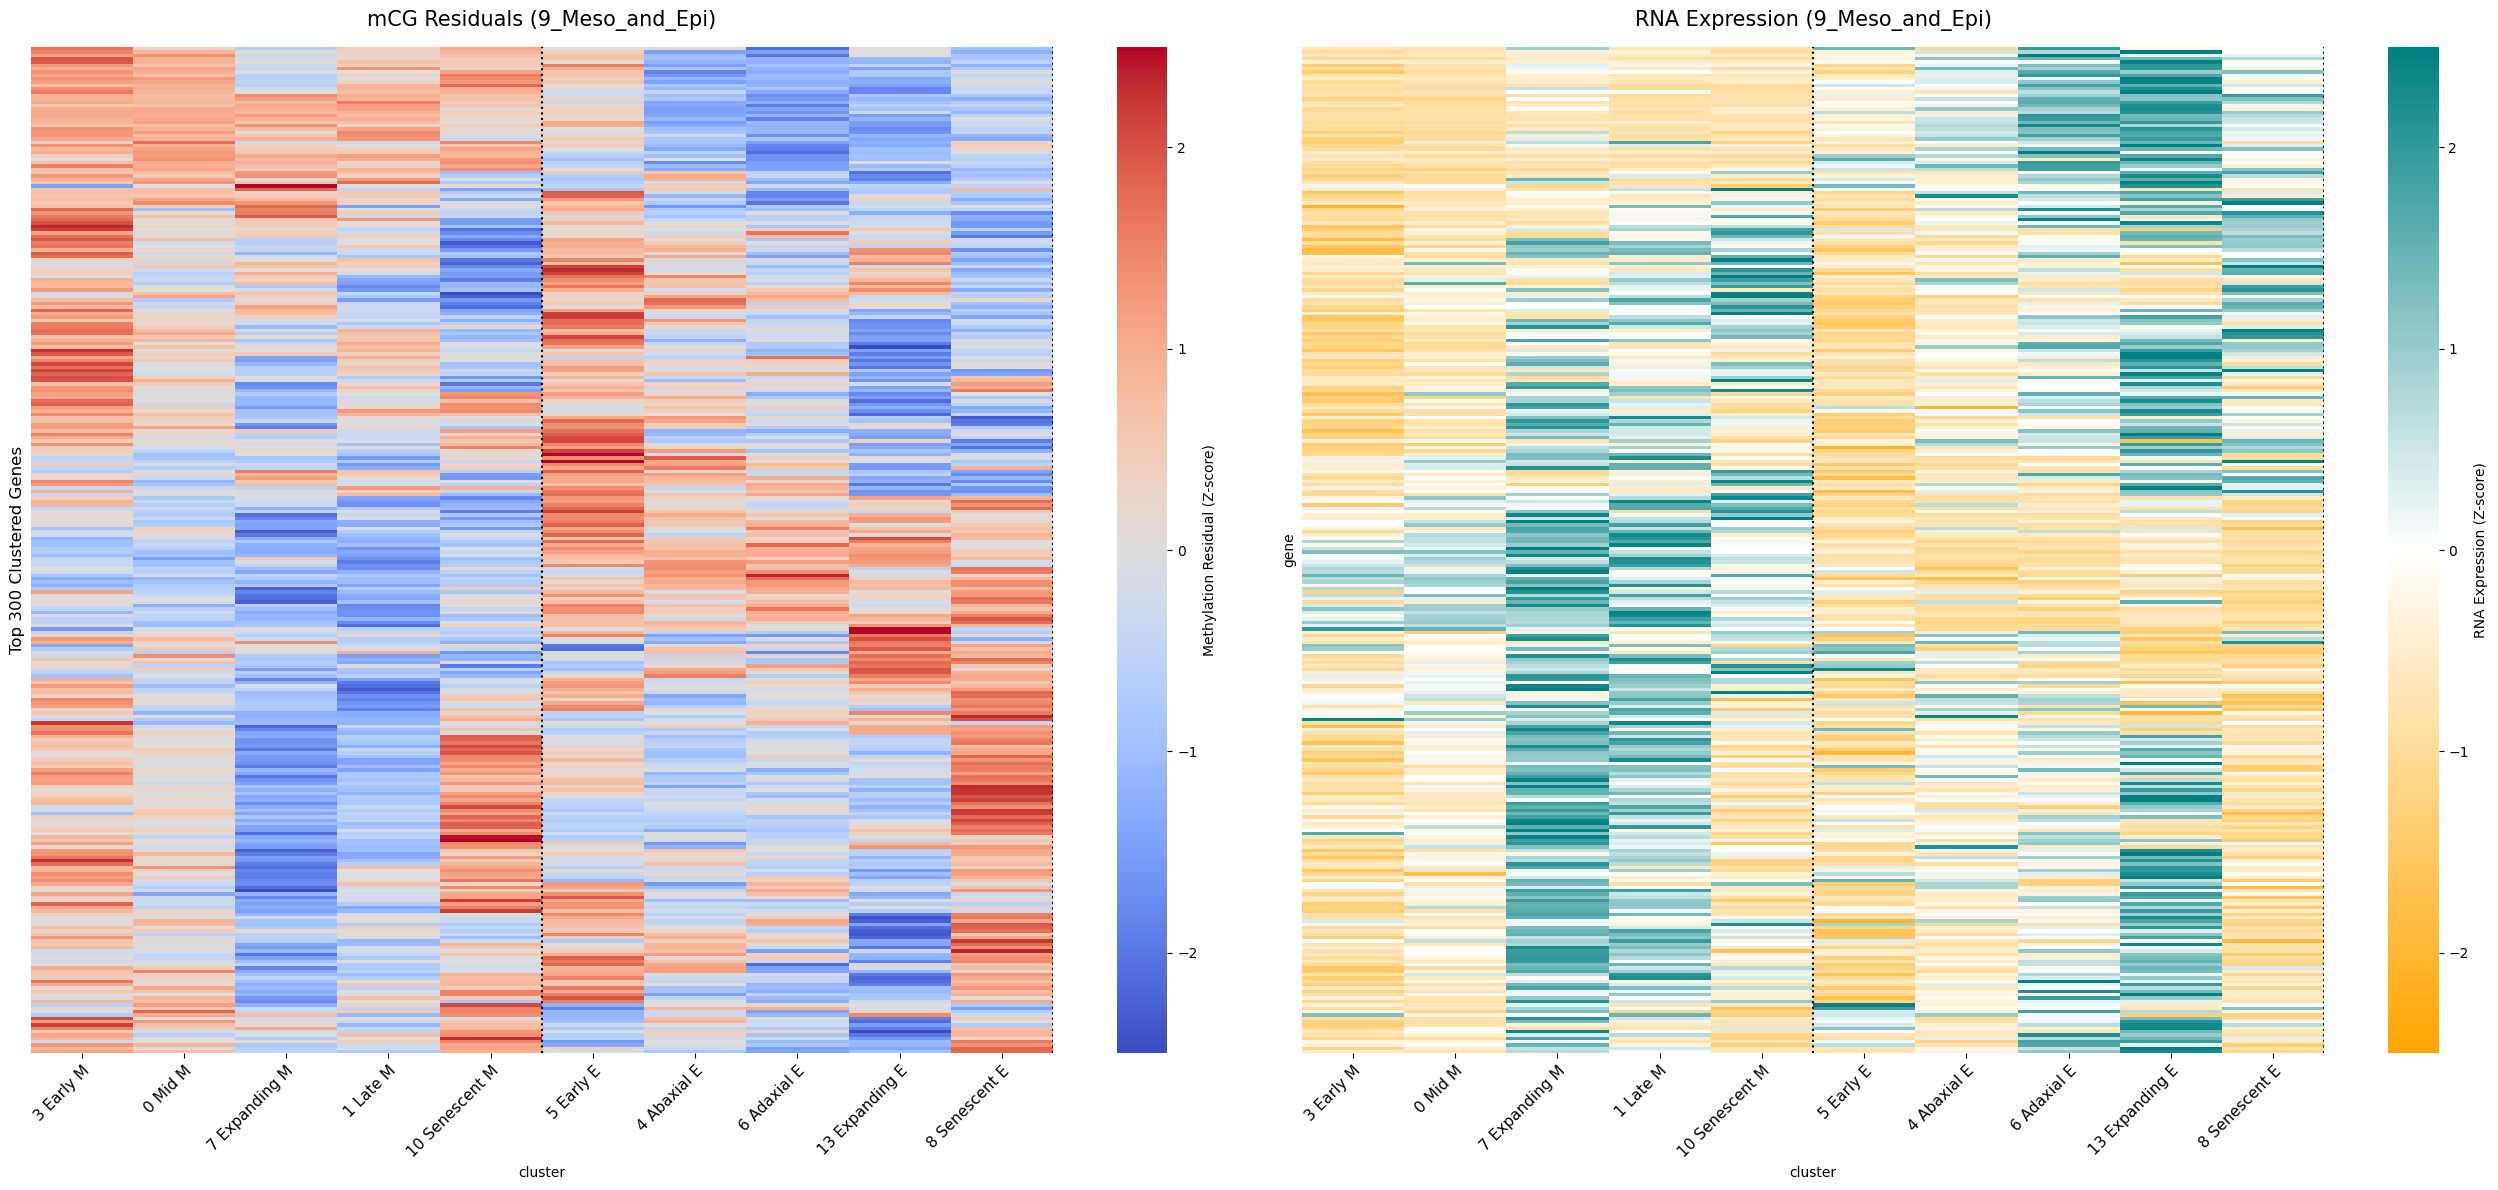


Success! All 9 Top-300 heatmap pairs have been restored and saved.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr, zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
import os

# Create output directory if it doesn't exist
os.makedirs("./figures/heatmaps", exist_ok=True)

# 1. Define mappings and expand them to catch any float/int column quirks
base_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
cluster_mapping = {}
for k, v in base_mapping.items():
    cluster_mapping[k] = v
    cluster_mapping[str(k)] = v
    cluster_mapping[float(k)] = v

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

# 2. Prepare the base dataframes using the renamed string columns
vis_meth_base = final_meth_df.rename(columns=cluster_mapping)
vis_rna_base = final_rna_df.rename(columns=cluster_mapping)

valid_cols = [c for c in cluster_order if c in vis_meth_base.columns]
vis_meth_base = vis_meth_base[valid_cols]
vis_rna_base = vis_rna_base[valid_cols]

# 3. Define specific groupings
mesophyll_clusters = [c for c in ['3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M'] if c in valid_cols]
epidermis_clusters = [c for c in ['5 Early E', '4 Abaxial E', '6 Adaxial E', '13 Expanding E', '8 Senescent E'] if c in valid_cols]

# Pre-calculate the Meta-States DataFrames (Analysis 2) using pseudo-bulk means
meth_meta = vis_meth_base.copy()
rna_meta = vis_rna_base.copy()

if mesophyll_clusters:
    meth_meta['Mesophyll Meta-state'] = meth_meta[mesophyll_clusters].mean(axis=1)
    rna_meta['Mesophyll Meta-state'] = rna_meta[mesophyll_clusters].mean(axis=1)
if epidermis_clusters:
    meth_meta['Epidermis Meta-state'] = meth_meta[epidermis_clusters].mean(axis=1)
    rna_meta['Epidermis Meta-state'] = rna_meta[epidermis_clusters].mean(axis=1)

meth_meta = meth_meta.drop(columns=mesophyll_clusters + epidermis_clusters)
rna_meta = rna_meta.drop(columns=mesophyll_clusters + epidermis_clusters)

meta_order = []
if mesophyll_clusters: meta_order.append('Mesophyll Meta-state')
if epidermis_clusters: meta_order.append('Epidermis Meta-state')
meta_order += [c for c in valid_cols if c not in mesophyll_clusters + epidermis_clusters]

meth_meta = meth_meta[meta_order]
rna_meta = rna_meta[meta_order]

# 4. Define the 9 Subsets for the loop
analyses = {
    "1_All_Clusters": valid_cols,
    "2_Meta_States": meta_order,
    "3_Mesophyll_Only": mesophyll_clusters,
    "4_Epidermis_Only": epidermis_clusters,
    "5_Non_Meso_Epi": [c for c in valid_cols if c in ['14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', '16 Myrosinase', '12 S phase', '15 G2M phase']],
    "6_Terminal_Non_Meso_Epi": [c for c in valid_cols if c in ['14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', '16 Myrosinase']],
    "7_Terminal_Ex_Guard": [c for c in valid_cols if c in ['2 Vasculature', '11 PPP', '9 Phloem', '16 Myrosinase']],
    "8_All_Ex_Guard_G2M": [c for c in valid_cols if c not in ['14 Guard cell', '15 G2M phase']],
    "9_Meso_and_Epi": mesophyll_clusters + epidermis_clusters
}

def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5).fillna(0)

# Orange for low, White for middle, Teal for high
rna_cmap = LinearSegmentedColormap.from_list("Orange_White_Teal", ["orange", "white", "teal"])

# ==========================================
# 5. Master Execution Loop
# ==========================================
for plot_name, cols in analyses.items():
    print(f"Processing: {plot_name}...")
    
    # Target the correct dataframe subset
    if plot_name == "2_Meta_States":
        sub_meth = meth_meta
        sub_rna = rna_meta
    else:
        sub_meth = vis_meth_base[cols]
        sub_rna = vis_rna_base[cols]
        
    # --- Recalculate Correlation specific to the subset ---
    valid_genes = []
    correlations = []
    
    for gene in sub_rna.index:
        r_vals = sub_rna.loc[gene].values
        m_vals = sub_meth.loc[gene].values
        
        # Skip genes with zero variance in this specific subset to avoid math errors
        if np.std(r_vals) == 0 or np.std(m_vals) == 0:
            continue
            
        rho, _ = spearmanr(r_vals, m_vals)
        if not np.isnan(rho):
            valid_genes.append(gene)
            correlations.append(rho)
            
    # Extract new Top 300 genes (Most negative rho = strongest inverse relationship)
    temp_stats = pd.DataFrame({'gene': valid_genes, 'rho': correlations}).set_index('gene')
    top_300_genes = temp_stats.sort_values('rho').head(300).index
    
    # --- Z-Score Generation ---
    vis_meth_z = prepare_zscore(sub_meth, top_300_genes)
    vis_rna_z = prepare_zscore(sub_rna, top_300_genes)
    
    # --- Hierarchical Clustering ---
    row_linkage = hc.linkage(sp.distance.pdist(vis_meth_z.values), method='ward')
    row_order = hc.leaves_list(row_linkage)
    clustered_genes = vis_meth_z.index[row_order]
    
    vis_meth_clustered = vis_meth_z.loc[clustered_genes]
    vis_rna_clustered = vis_rna_z.loc[clustered_genes]
    
    # --- Plotting ---
    # Fixed height for 300 genes, wide base (26) to stop horizontal squishing
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 12), gridspec_kw={'width_ratios': [1, 1]})

    # Methylation Heatmap (Coolwarm)
    sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1, 
                vmin=-2.5, vmax=2.5, rasterized=True,
                cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
    ax1.set_title(f"mCG Residuals ({plot_name})", fontsize=15, pad=15)
    ax1.set_ylabel(f"Top 300 Clustered Genes", fontsize=12)
    
    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax1.tick_params(axis='x', labelsize=11)

    # RNA Expression Heatmap (Orange-White-Teal)
    sns.heatmap(vis_rna_clustered, cmap=rna_cmap, center=0, ax=ax2, 
                vmin=-2.5, vmax=2.5, rasterized=True,
                cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
    ax2.set_title(f"RNA Expression ({plot_name})", fontsize=15, pad=15)
    
    ax2.set_xticks(ax2.get_xticks())
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax2.tick_params(axis='x', labelsize=11)

    # Dynamic Dividers (Includes meta-state boundaries)
    divider_positions = []
    for i, col_name in enumerate(cols):
        if "Senescent M" in col_name or "Senescent E" in col_name or "Meta-state" in col_name:
            divider_positions.append(i + 1)
            
    for ax in [ax1, ax2]:
        for pos in divider_positions:
            ax.axvline(pos, color='black', lw=1.5, linestyle=':')

    plt.tight_layout()
    
    # Save the SVG
    plt.savefig(f"./figures/heatmaps/rna_meth_wls_top300_{plot_name}_teal_orange.svg", format="svg", dpi=300, bbox_inches="tight")
    
    plt.show()
    plt.close() 
    
print("\nSuccess! All 9 Top-300 heatmap pairs have been restored and saved.")

In [9]:
# Create a dictionary to store the overlapping genes for each group
hazel_overlaps = {}

print("============================================================")
print(f"{'Analysis Group':<28} | {'Overlap Count':<15} | {'% of Top 300'}")
print("============================================================")

for plot_name, cols in analyses.items():
    # Target the correct dataframe subset
    if plot_name == "2_Meta_States":
        sub_meth = meth_meta
        sub_rna = rna_meta
    else:
        sub_meth = vis_meth_base[cols]
        sub_rna = vis_rna_base[cols]
        
    valid_genes = []
    correlations = []
    
    # Quick correlation run
    for gene in sub_rna.index:
        r_vals = sub_rna.loc[gene].values
        m_vals = sub_meth.loc[gene].values
        
        if np.std(r_vals) == 0 or np.std(m_vals) == 0:
            continue
            
        rho, _ = spearmanr(r_vals, m_vals)
        if not np.isnan(rho):
            valid_genes.append(gene)
            correlations.append(rho)
            
    # Extract Top 300 (Most negative rho)
    temp_stats = pd.DataFrame({'gene': valid_genes, 'rho': correlations}).set_index('gene')
    top_300_genes = temp_stats.sort_values('rho').head(300).index
    
    # --- FIND THE OVERLAP ---
    # Intersect the Top 300 with your c1038 (hazel_genes) list
    overlap = top_300_genes.intersection(hazel_genes)
    hazel_overlaps[plot_name] = overlap.tolist()
    
    # Print the row for the summary table
    pct = (len(overlap) / 300) * 100
    print(f"{plot_name:<28} | {len(overlap):<15} | {pct:.1f}%")

print("============================================================")
print("✅ Done! You can now access specific lists using the `hazel_overlaps` dictionary.")

Analysis Group               | Overlap Count   | % of Top 300
1_All_Clusters               | 84              | 28.0%
2_Meta_States                | 43              | 14.3%
3_Mesophyll_Only             | 31              | 10.3%
4_Epidermis_Only             | 28              | 9.3%
5_Non_Meso_Epi               | 21              | 7.0%
6_Terminal_Non_Meso_Epi      | 20              | 6.7%
7_Terminal_Ex_Guard          | 21              | 7.0%
8_All_Ex_Guard_G2M           | 83              | 27.7%
9_Meso_and_Epi               | 66              | 22.0%
✅ Done! You can now access specific lists using the `hazel_overlaps` dictionary.
